# Noise Distribution Analytics
Evaluates empirical scaling distributions and mapping to model convergence robustness.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ci_95(arr):
    if len(arr) < 2:
        return 0.0
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

cache_full = '../experiments/cache/noise_distribution.json'
cache_demo = '../experiments/cache/noise_distribution_demo.json'

cache_file = cache_full if os.path.exists(cache_full) else cache_demo
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        data = json.load(f)
else:
    print('Cache file not found.')
    data = {}

In [2]:
if data:
    records = []
    for key, val in data.items():
        if key in ['Reference', 'Teacher']:
            continue
        noise_cond = key
        for metric, arr in val.items():
            mean_val = np.mean(arr)
            err_val = ci_95(arr)
            records.append({'Noise Condition': noise_cond, 'Metric': metric, 'Mean': mean_val, 'Error': err_val})

    df = pd.DataFrame(records)
    from IPython.display import display
    display(df)

,Noise Condition,Metric,Mean,Error
0,Gaussian_Std1,Student (aux. only),0.50913,0.075382
1,Gaussian_Std1,Student (all logits),0.90148,0.008390
2,Gaussian_Std1,Cross-model (aux. only),0.20234,0.118772
3,Gaussian_Std1,Cross-model (all logits),0.74605,0.060903
4,Gaussian_Std0.01,Student (aux. only),0.36873,0.072530
5,Gaussian_Std0.01,Student (all logits),0.81118,0.027423
6,Gaussian_Std0.01,Cross-model (aux. only),0.09880,0.016608
7,Gaussian_Std0.01,Cross-model (all logits),0.59072,0.038401
8,Uniform_0_1,Student (aux. only),0.11760,0.009136
9,Uniform_0_1,Student (all logits),0.22065,0.035696


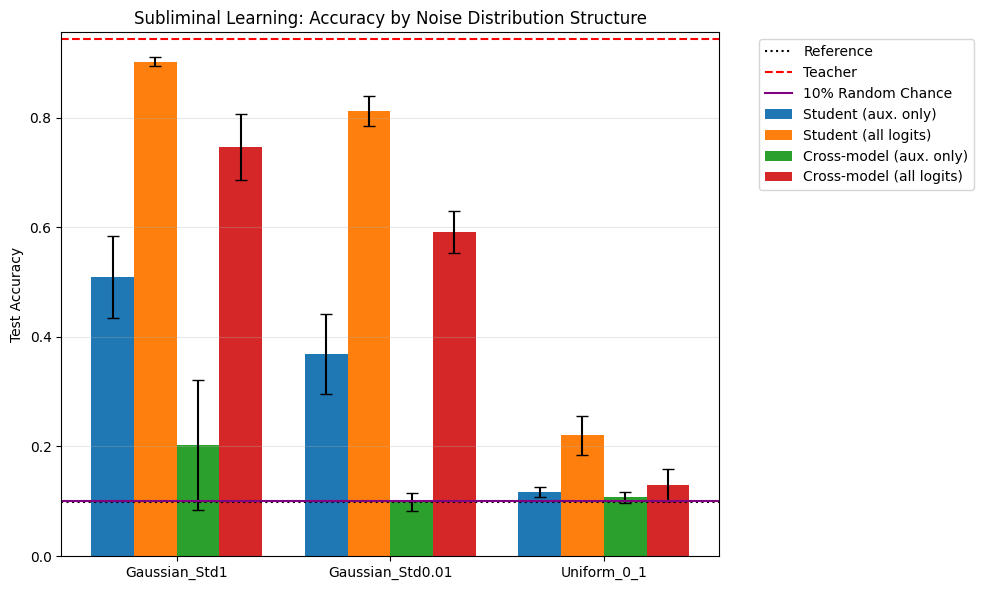

In [3]:
if data and 'df' in locals() and not df.empty:
    metrics = df['Metric'].unique()
    noise_conds = df['Noise Condition'].unique()
    
    x = np.arange(len(noise_conds))
    width = 0.20
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, metric in enumerate(metrics):
        subset = df[df['Metric'] == metric].set_index('Noise Condition')
        means = [subset.loc[nc, 'Mean'] if nc in subset.index else 0 for nc in noise_conds]
        errs = [subset.loc[nc, 'Error'] if nc in subset.index else 0 for nc in noise_conds]
        
        offset = width * i
        ax.bar(x + offset, means, width, yerr=errs, label=metric, capsize=4)
    
    if 'Reference' in data:
        ax.axhline(np.mean(data['Reference']), ls=':', c='black', label='Reference')
    if 'Teacher' in data:
        ax.axhline(np.mean(data['Teacher']), ls='--', c='red', label='Teacher')
        
    ax.axhline(0.10, ls='-', c='purple', label='10% Random Chance')
        
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Subliminal Learning: Accuracy by Noise Distribution Structure')
    ax.set_xticks(x + width * (len(metrics) - 1) / 2)
    ax.set_xticklabels(noise_conds)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    os.makedirs('../docs/reports', exist_ok=True)
    plt.savefig('../docs/reports/noise_distribution_chart.png', dpi=150)
    plt.show()